# DSA 5102 - Programming Assignment 1

## Description

As the first homework of this course, you will apply the knowledge you have learned in the first lecture on `linear models` and simple extensions using `kernel` methods on some datasets. This is also a chance to learn to use `jupyter notebook` and basic `sklearn` functionalities. A basic introduction to installing and using `jupyter notebooks` is found [here](https://www.datacamp.com/community/tutorials/tutorial-jupyter-notebook). You are strongly encouraged to use python 3 instead of python 2


The goals of this homework are
  * Learn basic data processing and machine learning using python
  * Reinforce knowledge on linear models and kernel methods
  * Prepare for the project in this course
  
Whenever you are stuck, you are encouraged to look at the jupyter notebook demonstration for the first lecture for some guidance. You should also learn to look at documentation of online libraries. For example, if you want to perform *kernel ridge regression* using `sklearn`, a quick google will land you on [this page](https://scikit-learn.org/stable/modules/kernel_ridge.html), where extensive description and examples are given.

## Instructions

Please complete each question below directly in this notebook. Note that you can write in the cells to describe what you are doing and any issues you face. If you are familiar, you can also format it using `markdown` as it is supported by `jupyter`. 

The grade given is based on the following
  1. Scientific correctness of your approach
  2. Clear documentation of your approach

## Dataset

We will work on a standard regression dataset on predicting concrete compressive strength from various composition and processing properties. 

We will download the dataset directly from the [UCI repository](https://archive.ics.uci.edu/ml/datasets/concrete+compressive+strength) using `urllib`. Running it requires an internet connection. Otherwise, you can also download the `Concrete_Data.xls` directly from the link above and place into the root folder relative to this notebook. 

Reading the Excel file requires the `xlrd` library on top of `pandas`. If you see an error due to not having xlrd, install it via
```
$pip install xlrd
```

In general, if you see an error 
```
ModuleNotFoundError: No module named 'some_module'
```
just install it
```
$pip install some_module
```

In [3]:
import pandas as pd
import urllib.request

In [4]:
# pip install xlrd

In [5]:
# url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls'
# urllib.request.urlretrieve(url, './Concrete_Data.xls')
data = pd.read_excel('./Concrete_Data.xls')

In [6]:
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## Question 1 (2 points)

In this homework we are going to predict the last column values (Concrete compressive strength) from design variables in the other columns. Choose 3 input properties and visualize each of their effects on the compressive strength. Plot your findings below. You may find the `seaborn` library examples in lecture 1 useful.

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
print(data.columns)

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')


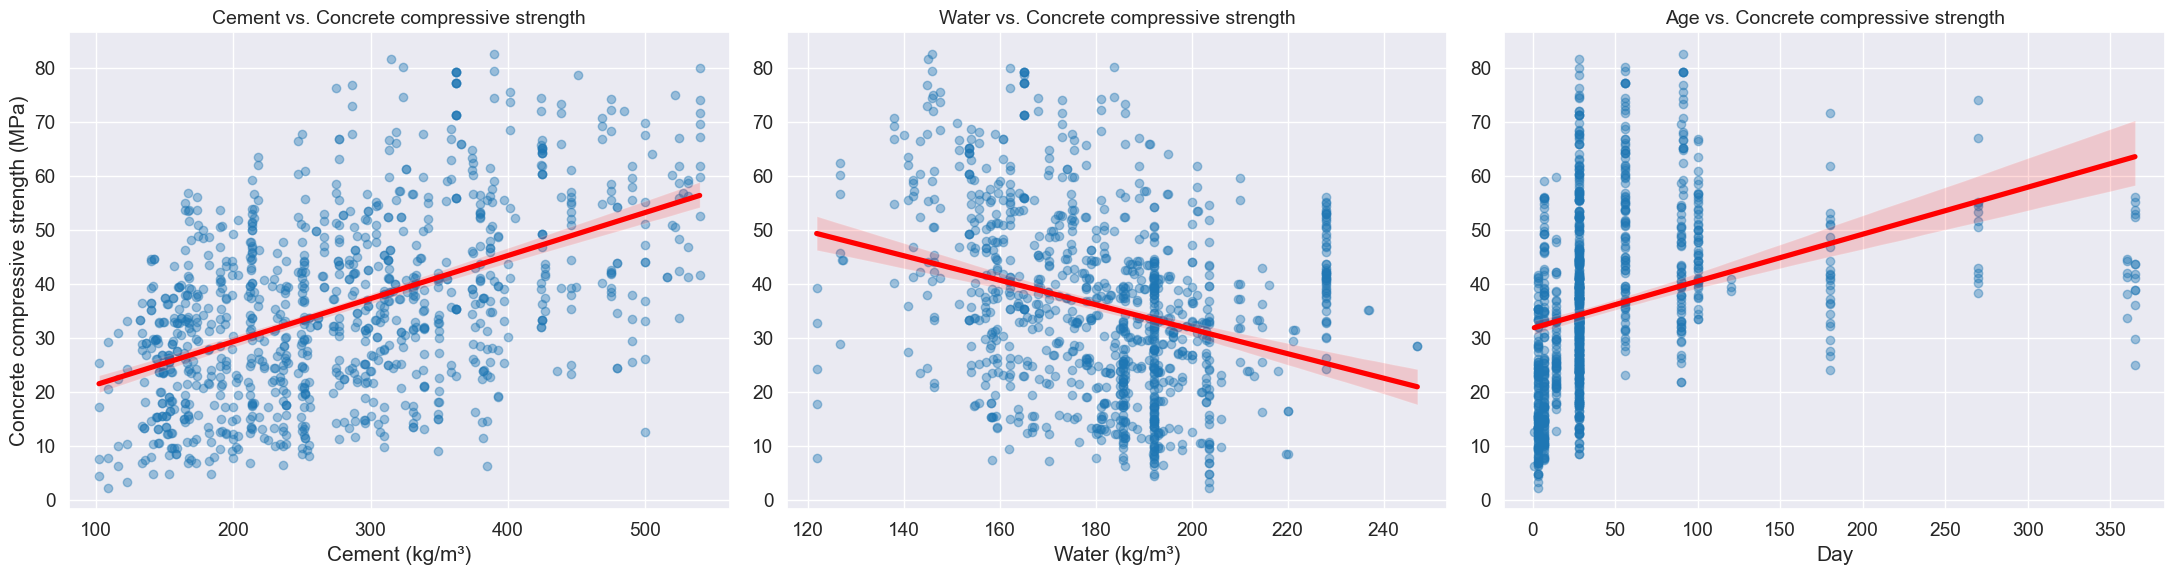

In [9]:
sns.set_context('notebook', font_scale=1.25, rc={"lines.linewidth": 2.5})
sns.set_style("darkgrid")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.regplot(
    ax=axes[0],  
    x='Cement (component 1)(kg in a m^3 mixture)', 
    y='Concrete compressive strength(MPa, megapascals) ', 
    data=data,
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)
axes[0].set_title('Cement vs. Concrete compressive strength', fontsize=14)
axes[0].set_xlabel('Cement (kg/m³)')
axes[0].set_ylabel('Concrete compressive strength (MPa)')

sns.regplot(
    ax=axes[1], 
    x='Water  (component 4)(kg in a m^3 mixture)', 
    y='Concrete compressive strength(MPa, megapascals) ', 
    data=data,
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)
axes[1].set_title('Water vs. Concrete compressive strength', fontsize=14)
axes[1].set_xlabel('Water (kg/m³)')
axes[1].set_ylabel('') 


sns.regplot(
    ax=axes[2],  
    x='Age (day)', 
    y='Concrete compressive strength(MPa, megapascals) ', 
    data=data,
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)
axes[2].set_title('Age vs. Concrete compressive strength', fontsize=14)
axes[2].set_xlabel('Day')
axes[2].set_ylabel('') 

plt.tight_layout()

plt.show()

## Question 2 (4 points)

Perform linear regression using all the input variables on this dataset to predict the compressive strength. Carefully evaluate your regression model using appropriate metrics and datasets. 

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np

In [33]:
X = data.drop(columns=['Concrete compressive strength(MPa, megapascals) '])
y = data['Concrete compressive strength(MPa, megapascals) ']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.1)

Model =  LinearRegression()

Model.fit(X_train, y_train)

y_predict = Model.predict(X_test)

In [34]:
mae = metrics.mean_absolute_error(y_test, y_predict)
mse = metrics.mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)  
r2 = metrics.r2_score(y_test, y_predict)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Scores: {r2:.2f}")

MAE: 8.84
MSE: 127.28
MSE: 11.28
R² Scores: 0.59


## Question 3 (4 points)

Now, instead of linear regression, apply kernel ridge regression (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html)) with 3 kernels:
1. Linear kernel
2. Polynomial kernel with degree 3
3. RBF (Gaussian) kernel

Quantify the performance improvement (if any) with respect to the linear case, and also the other kernels. What do you observe? Which would you choose?

*Hint: For the RBF kernel, should you do something to the inputs first? Why?*

---

Note: we have not gone through cross validation and hyper-parameter tuning yet, so you are not expected to do this here -- although you are free to do it if you know how. 

In [48]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler 

In [54]:
LinearKernelModel = KernelRidge(kernel='linear')

LinearKernelModel.fit(X_train, y_train)

y_lkpredict = LinearKernelModel.predict(X_test)

lk_mae = metrics.mean_absolute_error(y_test, y_lkpredict)
lk_mse = metrics.mean_squared_error(y_test, y_lkpredict)
lk_rmse = np.sqrt(lk_mse)  
lk_r2 = metrics.r2_score(y_test, y_lkpredict)

print(f"MAE: {lk_mae:.2f}")
print(f"MSE: {lk_mse:.2f}")
print(f"RMSE: {lk_rmse:.2f}")
print(f"R² Scores: {lk_r2:.2f}")

MAE: 8.87
MSE: 127.69
RMSE: 11.30
R² Scores: 0.59


In [59]:
PolyKernelModel = KernelRidge(kernel='polynomial', degree=3)

PolyKernelModel.fit(X_train, y_train)

y_pkpredict = PolyKernelModel.predict(X_test)

pk_mae = metrics.mean_absolute_error(y_test, y_pkpredict)
pk_mse = metrics.mean_squared_error(y_test, y_pkpredict)
pk_rmse = np.sqrt(pk_mse)  
pk_r2 = metrics.r2_score(y_test, y_pkpredict)

print(f"MAE: {pk_mae:.2f}")
print(f"MSE: {pk_mse:.2f}")
print(f"RMSE: {pk_rmse:.2f}")
print(f"R² Scores: {pk_r2:.2f}")

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


MAE: 4.69
MSE: 34.56
RMSE: 5.88
R² Scores: 0.89


In [57]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
RBFKernelModel = KernelRidge(kernel='rbf')

RBFKernelModel.fit(X_train_scaled, y_train)

y_rbfkpredict = RBFKernelModel.predict(X_test_scaled)

rbfk_mae = metrics.mean_absolute_error(y_test, y_rbfkpredict)
rbfk_mse = metrics.mean_squared_error(y_test, y_rbfkpredict)
rbfk_rmse = np.sqrt(pk_mse)  
rbfk_r2 = metrics.r2_score(y_test, y_rbfkpredict)

print(f"MAE: {rbfk_mae:.2f}")
print(f"MSE: {rbfk_mse:.2f}")
print(f"RMSE: {rbfk_rmse:.2f}")
print(f"R² Scores: {rbfk_r2:.2f}")

MAE: 5.88
MSE: 60.28
RMSE: 5.88
R² Scores: 0.80


When dealing with the RBF kernel，we need standardize the X. Because the calculation of RBF kernel is based on the distance between data. So if we don't standardize the data, the character with large value will dorminate, which leads that the model can't learn more information from other characters.